# Casting Quality Inspection — Data Exploration

This notebook explores the casting product image dataset used for the
**Automated Casting Defect Detection** project.

Class mapping:

| Folder | Meaning | Label |
|---|---|---|
| `ok_front` | Non-defective | `0` |
| `def_front` | Defective | `1` |

This notebook only explores the data. The actual training pipeline lives in `src/train.py`
(run with `python -m src.train`) so it can be reused outside of Jupyter.

In [1]:
import sys
from pathlib import Path

# Allow importing the `src` package when running this notebook from notebooks/
sys.path.append(str(Path.cwd().parent))

from src import config
from src.utils import validate_dataset_structure, DatasetValidationError
from src import data_analysis as da

## 1. Dataset path verification

In [2]:
print("Train dir:", config.TRAIN_DIR, "| exists:", config.TRAIN_DIR.exists())
print("Test dir: ", config.TEST_DIR, "| exists:", config.TEST_DIR.exists())

try:
    validate_dataset_structure()
    print("\nDataset structure looks valid.")
except DatasetValidationError as e:
    print("\nDataset validation FAILED:")
    print(e)
    print("\nPlace the Kaggle 'Casting Product Image Data for Quality Inspection'\n"
          "dataset into data/train/{ok_front,def_front} and data/test/{ok_front,def_front}\n"
          "before continuing.")

Train dir: C:\Users\ELCOT\Desktop\casting-quality-inspection\data\train | exists: True
Test dir:  C:\Users\ELCOT\Desktop\casting-quality-inspection\data\test | exists: True


INFO: Dataset validation passed.
INFO:   train/ok_front: 2875 images
INFO:   train/def_front: 3757 images
INFO:   test/ok_front: 262 images
INFO:   test/def_front: 453 images



Dataset structure looks valid.


## 2 & 8. Count images per class / class distribution

In [3]:
summary = da.summarize_dataset()
summary

{'train': {'ok_front': 2875, 'def_front': 3757},
 'test': {'ok_front': 262, 'def_front': 453},
 'train_total': 6632,
 'test_total': 715}

INFO: Saved: C:\Users\ELCOT\Desktop\casting-quality-inspection\reports\figures\class_distribution.png


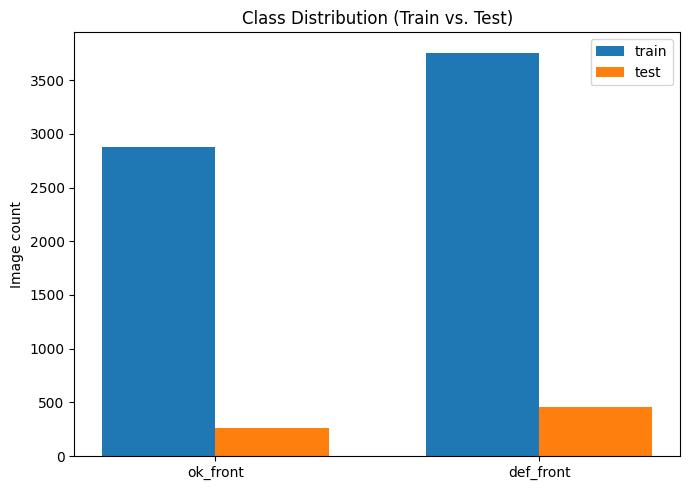

In [4]:
fig = da.plot_class_distribution(summary, save_path=config.FIGURES_DIR / "class_distribution.png")

## 3. Check class imbalance

A dataset is roughly balanced if neither class heavily outnumbers the other.
Significant imbalance (e.g. 90%/10%) would justify using `class_weight` during
training (see the *Optional Advanced Improvements* section of the README).

In [5]:
train_total = summary["train_total"]
if train_total > 0:
    for class_name, count in summary["train"].items():
        pct = 100 * count / train_total
        print(f"train/{class_name}: {count} images ({pct:.1f}%)")
else:
    print("No training images found yet -- add the dataset first.")

train/ok_front: 2875 images (43.4%)
train/def_front: 3757 images (56.6%)


## 4. Sample non-defective images (`ok_front`)

INFO: Saved: C:\Users\ELCOT\Desktop\casting-quality-inspection\reports\figures\sample_ok_front.png


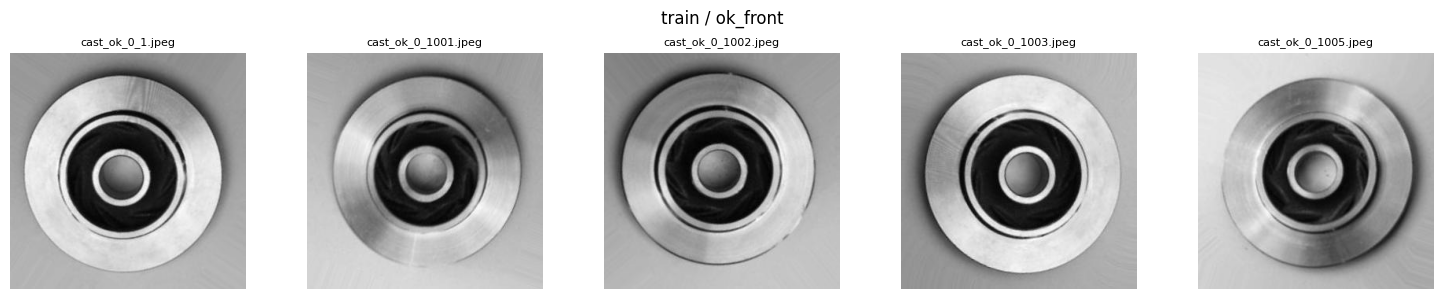

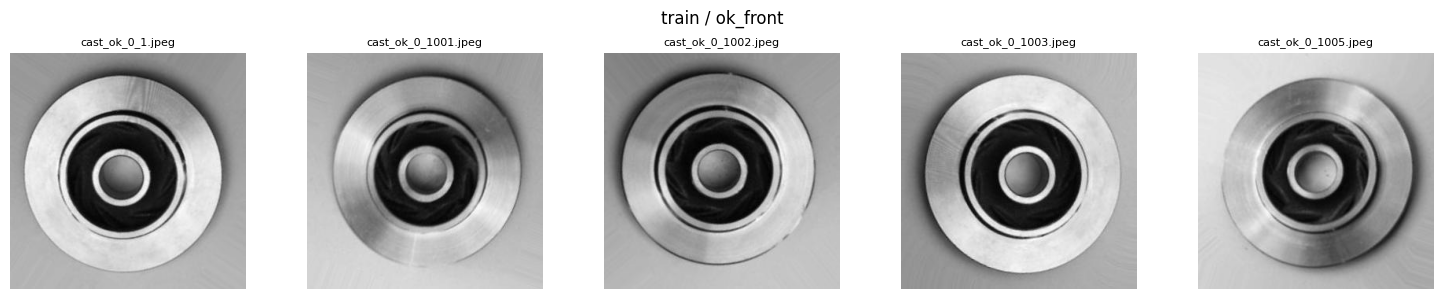

In [6]:
da.plot_sample_images("ok_front", split="train", n=5,
                       save_path=config.FIGURES_DIR / "sample_ok_front.png")

## 5. Sample defective images (`def_front`)

INFO: Saved: C:\Users\ELCOT\Desktop\casting-quality-inspection\reports\figures\sample_def_front.png


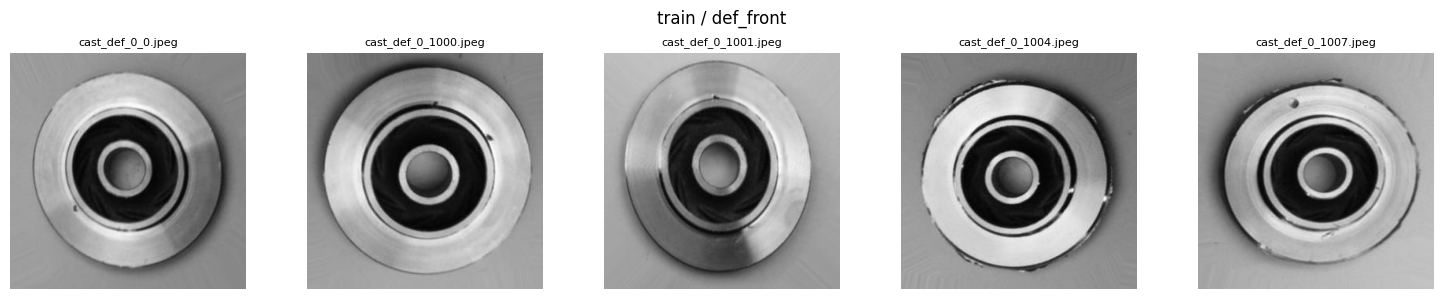

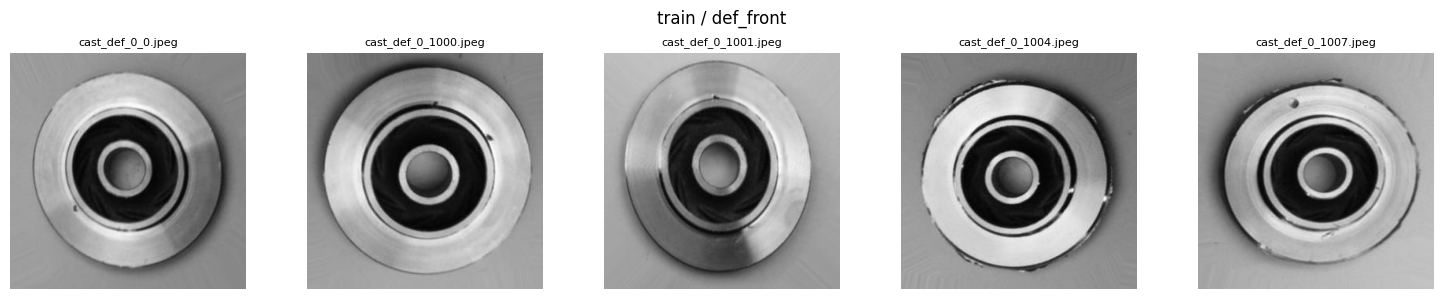

In [7]:
da.plot_sample_images("def_front", split="train", n=5,
                       save_path=config.FIGURES_DIR / "sample_def_front.png")

## 6. Image dimensions (sample check)

In [8]:
for class_name in config.CLASS_FOLDER_NAMES:
    dims = da.get_image_dimensions_sample(class_name, split="train", n=20)
    unique_dims = sorted(set(dims))
    print(f"{class_name}: sampled {len(dims)} images, unique dimensions found: {unique_dims}")

ok_front: sampled 20 images, unique dimensions found: [(300, 300)]
def_front: sampled 20 images, unique dimensions found: [(300, 300)]


## 7. Check for corrupted / unreadable images

This scans every image in the training set with Pillow's `verify()`. On large
datasets this may take a moment.

In [9]:
broken = da.find_corrupted_images(split="train")
for class_name, broken_files in broken.items():
    print(f"{class_name}: {len(broken_files)} corrupted/unreadable file(s)")
    for f in broken_files:
        print("  -", f)

ok_front: 0 corrupted/unreadable file(s)
def_front: 0 corrupted/unreadable file(s)


## 9. Business meaning of each class

- **`ok_front` (label 0, Non-defective):** The casting product passed visual
  inspection. It can proceed to packaging/shipping.
- **`def_front` (label 1, Defective):** The casting product shows a visible
  defect (e.g. crack, hole, rough surface, irregular boundary). It should be
  routed to manual review or removed from the line.

In this system, a **false negative** (a defective part predicted as
non-defective) is the costliest error, because it risks a defective product
reaching the customer. This motivates reporting recall and running a
threshold analysis in `src/evaluate.py`, in addition to plain accuracy.

## 10. Summary

All generated figures in this notebook are saved under `reports/figures/` for
reuse in the README and project report. Proceed to training 
